# Reliability Modeling: Crow-AMSAA, Cox-Lewis, Gompertz & Weibull NHPP

This notebook demonstrates how to:
1. Generate synthetic failure data
2. Fit multiple reliability models (Crow-AMSAA, Cox-Lewis, Gompertz, Weibull NHPP) to extract meaningful parameters
3. Use piecewise modeling to capture changing trends
4. Compare models and visualize parameter interpretation
5. Use parameters as features for assessing preventive maintenance effectiveness


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline


## Crow-AMSAA Model Implementation

The Crow-AMSAA model: **N(t) = λ × t^β**

- **λ (lambda)**: Scale parameter - affects the overall failure rate
- **β (beta)**: Shape parameter - indicates reliability trend
  - β < 1: Reliability growth (failures become less frequent)
  - β = 1: Constant failure rate (exponential process)
  - β > 1: Reliability decay (failures become more frequent)


In [58]:
class CrowAMSAA:
    """Crow-AMSAA reliability growth model."""
    
    def __init__(self):
        self.lambda_param = None
        self.beta_param = None
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None):
        """Fit model to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 2:
            raise ValueError("Need at least 2 failures to fit model")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        def neg_log_likelihood(params):
            lam, beta = params
            if lam <= 0 or beta <= 0:
                return 1e10
            
            if censoring_time == failure_times[-1]:
                # Complete data
                log_likelihood = n * np.log(lam * beta)
                log_likelihood += (beta - 1) * np.sum(np.log(failure_times))
                log_likelihood -= lam * np.sum(failure_times ** beta)
            else:
                # Censored data
                log_likelihood = n * np.log(lam * beta)
                log_likelihood += (beta - 1) * np.sum(np.log(failure_times))
                log_likelihood -= lam * censoring_time ** beta
            
            return -log_likelihood
        
        # Initial estimates
        if n > 1:
            initial_beta = n / np.sum(np.log(censoring_time / failure_times))
        else:
            initial_beta = 1.0
        initial_lambda = n / (censoring_time ** initial_beta)
        
        # Optimize
        result = minimize(
            neg_log_likelihood,
            x0=[initial_lambda, initial_beta],
            method='L-BFGS-B',
            bounds=[(1e-10, None), (1e-10, None)]
        )
        
        if not result.success:
            # Fallback to method of moments
            initial_beta = n / np.sum(np.log(censoring_time / failure_times))
            initial_lambda = n / (censoring_time ** initial_beta)
            self.lambda_param, self.beta_param = initial_lambda, initial_beta
        else:
            self.lambda_param, self.beta_param = result.x
        
        self.fitted = True
        return self.lambda_param, self.beta_param
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        return self.lambda_param * (time ** self.beta_param)
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        return self.lambda_param * self.beta_param * (time ** (self.beta_param - 1))
    
    def get_reliability_trend(self):
        """Interpret beta parameter."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        if self.beta_param < 0.95:
            return "Growth"
        elif self.beta_param > 1.05:
            return "Decay"
        else:
            return "Constant"


class PiecewiseCrowAMSAA:
    """Piecewise Crow-AMSAA model for handling changing trends."""
    
    def __init__(self, n_segments=2):
        """
        Initialize piecewise model.
        
        Parameters:
        -----------
        n_segments : int
            Number of segments (default: 2)
        """
        self.n_segments = n_segments
        self.segments = []
        self.change_points = []
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None, change_points=None):
        """
        Fit piecewise Crow-AMSAA model.
        
        Parameters:
        -----------
        failure_times : array-like
            Failure times
        censoring_time : float, optional
            Total observation time
        change_points : array-like, optional
            Known change points. If None, will estimate them.
        """
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        if change_points is None:
            # Estimate change points by dividing time into segments
            change_points = np.linspace(0, censoring_time, self.n_segments + 1)[1:-1]
        
        self.change_points = np.sort(change_points)
        self.segments = []
        
        # Fit model for each segment
        segment_start = 0
        for i, change_point in enumerate(self.change_points):
            # Get failures in this segment
            segment_failures = failure_times[
                (failure_times >= segment_start) & (failure_times < change_point)
            ]
            
            if len(segment_failures) < 2:
                # Not enough data, skip or use previous segment
                continue
            
            # Shift times to start from 0 for this segment
            segment_failures_shifted = segment_failures - segment_start
            
            # Fit Crow-AMSAA for this segment
            model = CrowAMSAA()
            try:
                model.fit(segment_failures_shifted, change_point - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': change_point,
                    'lambda': model.lambda_param,
                    'beta': model.beta_param
                })
            except:
                pass
            
            segment_start = change_point
        
        # Final segment
        final_failures = failure_times[failure_times >= segment_start]
        if len(final_failures) >= 2:
            final_failures_shifted = final_failures - segment_start
            model = CrowAMSAA()
            try:
                model.fit(final_failures_shifted, censoring_time - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': censoring_time,
                    'lambda': model.lambda_param,
                    'beta': model.beta_param
                })
            except:
                pass
        
        self.fitted = True
        return self.segments
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        if len(self.segments) == 0:
            return 0
        
        cumulative = 0
        
        # Accumulate cumulative from all completed segments
        for i, segment in enumerate(self.segments):
            if time < segment['start']:
                break
            elif time <= segment['end']:
                # Time is in this segment
                segment_time = time - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative += segment_cumulative
                break
            else:
                # Time is past this segment, add all failures from this segment
                segment_time = segment['end'] - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative += segment_cumulative
        
        return cumulative
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        for segment in self.segments:
            if segment['start'] <= time <= segment['end']:
                segment_time = time - segment['start']
                return segment['model'].predict_failure_rate(segment_time)
        
        # If past all segments, use last segment
        if len(self.segments) > 0:
            last_seg = self.segments[-1]
            segment_time = time - last_seg['start']
            return last_seg['model'].predict_failure_rate(segment_time)
        
        return 0
    
    def get_segment_parameters(self):
        """Get parameters for each segment."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        return self.segments


class CoxLewis:
    """Cox-Lewis reliability model with exponential failure rate."""
    
    def __init__(self):
        self.alpha_param = None
        self.gamma_param = None
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None):
        """Fit Cox-Lewis model to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 2:
            raise ValueError("Need at least 2 failures to fit model")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        def neg_log_likelihood(params):
            alpha, gamma = params
            if not np.isfinite(alpha) or not np.isfinite(gamma):
                return 1e10
            
            try:
                # Log-likelihood for Cox-Lewis
                # λ(t) = exp(α + γt)
                # Cumulative intensity: Λ(t) = (exp(α)/γ) * (exp(γt) - 1) if γ ≠ 0
                #                        = exp(α) * t if γ = 0
                
                if abs(gamma) < 1e-10:
                    # γ ≈ 0: constant rate
                    integral = np.exp(alpha) * censoring_time
                else:
                    integral = (np.exp(alpha) / gamma) * (np.exp(gamma * censoring_time) - 1)
                
                log_likelihood = np.sum(alpha + gamma * failure_times) - integral
                
                if not np.isfinite(log_likelihood):
                    return 1e10
                
                return -log_likelihood
            except:
                return 1e10
        
        # Initial estimates
        # Use method of moments approximation
        if n > 1:
            # Estimate gamma from trend in failure intervals
            intervals = np.diff(np.concatenate([[0], failure_times]))
            if len(intervals) > 1:
                x = np.arange(len(intervals))
                slope = np.polyfit(x, intervals, 1)[0]
                # If intervals increasing, gamma < 0 (improving)
                # If intervals decreasing, gamma > 0 (degrading)
                gamma0 = -slope / (np.mean(intervals) ** 2) if np.mean(intervals) > 0 else 0.0
                gamma0 = np.clip(gamma0, -0.1, 0.1)
            else:
                gamma0 = 0.0
            
            # Estimate alpha
            if abs(gamma0) < 1e-10:
                alpha0 = np.log(n / censoring_time) if censoring_time > 0 else -3.0
            else:
                alpha0 = np.log((n * gamma0) / (np.exp(gamma0 * censoring_time) - 1))
            alpha0 = np.clip(alpha0, -10, 0)
        else:
            alpha0, gamma0 = -3.0, 0.0
        
        # Optimize
        result = minimize(
            neg_log_likelihood,
            x0=[alpha0, gamma0],
            method='L-BFGS-B',
            bounds=[(-10, 0), (-0.1, 0.1)]
        )
        
        if not result.success:
            self.alpha_param, self.gamma_param = alpha0, gamma0
        else:
            self.alpha_param, self.gamma_param = result.x
        
        self.fitted = True
        return self.alpha_param, self.gamma_param
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        return np.exp(self.alpha_param + self.gamma_param * time)
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        if abs(self.gamma_param) < 1e-10:
            return np.exp(self.alpha_param) * time
        else:
            return (np.exp(self.alpha_param) / self.gamma_param) * (np.exp(self.gamma_param * time) - 1)
    
    def get_reliability_trend(self):
        """Interpret gamma parameter."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        if self.gamma_param < -0.01:
            return "Growth"
        elif self.gamma_param > 0.01:
            return "Decay"
        else:
            return "Constant"


class PiecewiseCoxLewis:
    """Piecewise Cox-Lewis model for handling changing trends."""
    
    def __init__(self, n_segments=2):
        self.n_segments = n_segments
        self.segments = []
        self.change_points = []
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None, change_points=None):
        """Fit piecewise Cox-Lewis model."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        if change_points is None:
            change_points = np.linspace(0, censoring_time, self.n_segments + 1)[1:-1]
        
        self.change_points = np.sort(change_points)
        self.segments = []
        
        segment_start = 0
        for i, change_point in enumerate(self.change_points):
            segment_failures = failure_times[
                (failure_times >= segment_start) & (failure_times < change_point)
            ]
            
            if len(segment_failures) < 2:
                continue
            
            segment_failures_shifted = segment_failures - segment_start
            
            model = CoxLewis()
            try:
                model.fit(segment_failures_shifted, change_point - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': change_point,
                    'alpha': model.alpha_param,
                    'gamma': model.gamma_param
                })
            except:
                pass
            
            segment_start = change_point
        
        # Final segment
        final_failures = failure_times[failure_times >= segment_start]
        if len(final_failures) >= 2:
            final_failures_shifted = final_failures - segment_start
            model = CoxLewis()
            try:
                model.fit(final_failures_shifted, censoring_time - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': censoring_time,
                    'alpha': model.alpha_param,
                    'gamma': model.gamma_param
                })
            except:
                pass
        
        self.fitted = True
        return self.segments
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        if len(self.segments) == 0:
            return 0
        
        cumulative = 0
        
        for i, segment in enumerate(self.segments):
            if time < segment['start']:
                break
            elif time <= segment['end']:
                segment_time = time - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative += segment_cumulative
                break
            else:
                segment_time = segment['end'] - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative += segment_cumulative
        
        return cumulative
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        for segment in self.segments:
            if segment['start'] <= time <= segment['end']:
                segment_time = time - segment['start']
                return segment['model'].predict_failure_rate(segment_time)
        
        # If past all segments, use last segment
        if len(self.segments) > 0:
            last_seg = self.segments[-1]
            segment_time = time - last_seg['start']
            return last_seg['model'].predict_failure_rate(segment_time)
        
        return 0
    
    def get_segment_parameters(self):
        """Get parameters for each segment."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        return self.segments


class Gompertz:
    """
    Gompertz reliability growth model.
    
    Standard formulation for reliability growth:
    Cumulative failures: N(t) = a * (1 - exp(-b * (1 - c^t)))
    Failure rate: λ(t) = a * b * ln(c) * c^t * exp(-b * (1 - c^t))
    
    Parameters:
    - a: Asymptotic number of failures (upper limit)
    - b: Growth parameter (b > 0)
    - c: Growth rate parameter (0 < c < 1 for growth, c > 1 for decay)
    """
    
    def __init__(self):
        self.a_param = None
        self.b_param = None
        self.c_param = None
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None):
        """Fit Gompertz model to failure data using least squares."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 3:
            raise ValueError("Need at least 3 failures to fit Gompertz model")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        # Actual cumulative failures
        actual_cumulative = np.arange(1, n + 1)
        
        def residual_sum_squares(params):
            a, b, c = params
            if a <= 0 or b <= 0 or c <= 0:
                return 1e10
            
            try:
                # Predict cumulative for each failure time
                predicted = np.array([a * (1 - np.exp(-b * (1 - c**t))) for t in failure_times])
                
                # RSS
                rss = np.sum((predicted - actual_cumulative)**2)
                
                if not np.isfinite(rss):
                    return 1e10
                
                return rss
            except:
                return 1e10
        
        # Better initial estimates based on data
        # Estimate asymptotic value from final failures
        a0 = max(n * 1.2, actual_cumulative[-1] * 1.1)
        
        # Estimate growth parameters
        # If failures are slowing down, b should be larger
        if n >= 3:
            # Check if rate is decreasing
            intervals = np.diff(failure_times)
            if len(intervals) > 1:
                rate_trend = (intervals[-1] - intervals[0]) / intervals[0]
                if rate_trend > 0:  # Intervals increasing = rate decreasing
                    b0 = 2.0  # Stronger growth
                else:
                    b0 = 0.5  # Weaker growth
            else:
                b0 = 1.0
        else:
            b0 = 1.0
        
        # c should be between 0 and 1 for growth
        c0 = 0.95  # Start with slow growth
        
        # Try multiple starting points
        best_rss = 1e10
        best_params = [a0, b0, c0]
        
        for a_init in [a0, a0 * 0.8, a0 * 1.2]:
            for b_init in [b0, b0 * 0.5, b0 * 2.0]:
                for c_init in [0.85, 0.90, 0.95, 0.98]:
                    result = minimize(
                        residual_sum_squares,
                        x0=[a_init, b_init, c_init],
                        method='L-BFGS-B',
                        bounds=[(1e-5, None), (1e-5, 10), (1e-5, 0.999)]
                    )
                    if result.success and result.fun < best_rss:
                        best_rss = result.fun
                        best_params = result.x
        
        self.a_param, self.b_param, self.c_param = best_params
        self.fitted = True
        return self.a_param, self.b_param, self.c_param
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        if time <= 0:
            return 0
        return self.a_param * (1 - np.exp(-self.b_param * (1 - self.c_param**time)))
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        if time <= 0:
            return 0
        return self.a_param * self.b_param * np.log(self.c_param) * \
               (self.c_param**time) * np.exp(-self.b_param * (1 - self.c_param**time))
    
    def get_reliability_trend(self):
        """Interpret model parameters."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        # c < 1 means growth (reliability improving)
        # c close to 1 means slow growth
        # c close to 0 means rapid growth initially
        if self.c_param < 0.95:
            return "Growth"
        else:
            return "Slow Growth"


class WeibullNHPP:
    """
    Weibull Non-Homogeneous Poisson Process (NHPP) model.
    
    Formula: λ(t) = (β/η) * (t/η)^(β-1)
    Cumulative: N(t) = (t/η)^β
    
    Parameters:
    - η (eta): Scale parameter (characteristic life)
    - β (beta): Shape parameter
      - β < 1: Decreasing failure rate (reliability growth)
      - β = 1: Constant failure rate (exponential)
      - β > 1: Increasing failure rate (wear-out)
    """
    
    def __init__(self):
        self.eta_param = None
        self.beta_param = None
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None):
        """Fit Weibull NHPP model to failure data."""
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if n < 2:
            raise ValueError("Need at least 2 failures to fit model")
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        def neg_log_likelihood(params):
            eta, beta = params
            if eta <= 0 or beta <= 0:
                return 1e10
            
            try:
                # Weibull NHPP intensity: λ(t) = (β/η) * (t/η)^(β-1)
                # Cumulative: N(t) = (t/η)^β
                
                # Log-likelihood
                log_likelihood = n * np.log(beta / eta)
                log_likelihood += (beta - 1) * np.sum(np.log(failure_times / eta))
                log_likelihood -= (censoring_time / eta) ** beta
                
                if not np.isfinite(log_likelihood):
                    return 1e10
                
                return -log_likelihood
            except:
                return 1e10
        
        # Initial estimates using method of moments
        if n > 1:
            # Estimate beta from failure intervals
            intervals = np.diff(np.concatenate([[0], failure_times]))
            if len(intervals) > 1 and np.mean(intervals) > 0:
                # Rough estimate: if intervals increasing, beta > 1
                # If intervals decreasing, beta < 1
                slope = np.polyfit(np.arange(len(intervals)), intervals, 1)[0]
                if slope > 0:
                    beta0 = 1.2
                elif slope < 0:
                    beta0 = 0.8
                else:
                    beta0 = 1.0
            else:
                beta0 = 1.0
        else:
            beta0 = 1.0
        
        # Estimate eta
        eta0 = censoring_time / (n ** (1 / beta0)) if n > 0 else censoring_time
        
        # Optimize
        result = minimize(
            neg_log_likelihood,
            x0=[eta0, beta0],
            method='L-BFGS-B',
            bounds=[(1e-5, None), (1e-5, None)]
        )
        
        if not result.success:
            self.eta_param, self.beta_param = eta0, beta0
        else:
            self.eta_param, self.beta_param = result.x
        
        self.fitted = True
        return self.eta_param, self.beta_param
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        return (time / self.eta_param) ** self.beta_param
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        if time <= 0:
            return 0
        return (self.beta_param / self.eta_param) * ((time / self.eta_param) ** (self.beta_param - 1))
    
    def get_reliability_trend(self):
        """Interpret beta parameter."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        if self.beta_param < 0.95:
            return "Growth"
        elif self.beta_param > 1.05:
            return "Decay"
        else:
            return "Constant"


class PiecewiseWeibullNHPP:
    """Piecewise Weibull NHPP model for handling changing trends."""
    
    def __init__(self, n_segments=2):
        """
        Initialize piecewise model.
        
        Parameters:
        -----------
        n_segments : int
            Number of segments (default: 2)
        """
        self.n_segments = n_segments
        self.segments = []
        self.change_points = []
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None, change_points=None):
        """
        Fit piecewise Weibull NHPP model.
        
        Parameters:
        -----------
        failure_times : array-like
            Failure times
        censoring_time : float, optional
            Total observation time
        change_points : array-like, optional
            Known change points. If None, will estimate them.
        """
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        if change_points is None:
            # Estimate change points by dividing time into segments
            change_points = np.linspace(0, censoring_time, self.n_segments + 1)[1:-1]
        
        self.change_points = np.sort(change_points)
        self.segments = []
        
        # Fit model for each segment
        segment_start = 0
        cumulative_offset = 0
        
        for i, change_point in enumerate(self.change_points):
            # Get failures in this segment
            segment_failures = failure_times[
                (failure_times >= segment_start) & (failure_times < change_point)
            ]
            
            if len(segment_failures) < 2:
                # Not enough data, skip
                segment_start = change_point
                continue
            
            # Shift times to start from 0 for this segment
            segment_failures_shifted = segment_failures - segment_start
            
            # Fit Weibull NHPP for this segment
            model = WeibullNHPP()
            try:
                model.fit(segment_failures_shifted, change_point - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': change_point,
                    'eta': model.eta_param,
                    'beta': model.beta_param,
                    'cumulative_offset': cumulative_offset
                })
                # Update cumulative offset for next segment
                segment_cumulative = model.predict_cumulative(change_point - segment_start)
                cumulative_offset += segment_cumulative
            except:
                pass
            
            segment_start = change_point
        
        # Final segment
        final_failures = failure_times[failure_times >= segment_start]
        if len(final_failures) >= 2:
            final_failures_shifted = final_failures - segment_start
            model = WeibullNHPP()
            try:
                model.fit(final_failures_shifted, censoring_time - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': censoring_time,
                    'eta': model.eta_param,
                    'beta': model.beta_param,
                    'cumulative_offset': cumulative_offset
                })
            except:
                pass
        
        self.fitted = True
        return self.segments
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        if len(self.segments) == 0:
            return 0
        
        cumulative = 0
        
        # Accumulate cumulative from all completed segments
        for i, segment in enumerate(self.segments):
            if time < segment['start']:
                break
            elif time <= segment['end']:
                # Time is in this segment
                segment_time = time - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative = segment['cumulative_offset'] + segment_cumulative
                break
            else:
                # Time is past this segment, add all failures from this segment
                segment_time = segment['end'] - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative = segment['cumulative_offset'] + segment_cumulative
        
        return cumulative
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        for segment in self.segments:
            if segment['start'] <= time <= segment['end']:
                segment_time = time - segment['start']
                return segment['model'].predict_failure_rate(segment_time)
        
        # If past all segments, use last segment
        if len(self.segments) > 0:
            last_seg = self.segments[-1]
            segment_time = time - last_seg['start']
            return last_seg['model'].predict_failure_rate(segment_time)
        
        return 0
    
    def get_segment_parameters(self):
        """Get parameters for each segment."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        return self.segments


class PiecewiseGompertz:
    """Piecewise Gompertz model for handling changing trends."""
    
    def __init__(self, n_segments=2):
        """
        Initialize piecewise model.
        
        Parameters:
        -----------
        n_segments : int
            Number of segments (default: 2)
        """
        self.n_segments = n_segments
        self.segments = []
        self.change_points = []
        self.fitted = False
    
    def fit(self, failure_times, censoring_time=None, change_points=None):
        """
        Fit piecewise Gompertz model.
        
        Parameters:
        -----------
        failure_times : array-like
            Failure times
        censoring_time : float, optional
            Total observation time
        change_points : array-like, optional
            Known change points. If None, will estimate them.
        """
        failure_times = np.sort(failure_times)
        n = len(failure_times)
        
        if censoring_time is None:
            censoring_time = failure_times[-1]
        
        if change_points is None:
            # Estimate change points by dividing time into segments
            change_points = np.linspace(0, censoring_time, self.n_segments + 1)[1:-1]
        
        self.change_points = np.sort(change_points)
        self.segments = []
        
        # Fit model for each segment
        segment_start = 0
        cumulative_offset = 0
        
        for i, change_point in enumerate(self.change_points):
            # Get failures in this segment
            segment_failures = failure_times[
                (failure_times >= segment_start) & (failure_times < change_point)
            ]
            
            if len(segment_failures) < 3:
                # Not enough data, skip
                segment_start = change_point
                continue
            
            # Shift times to start from 0 for this segment
            segment_failures_shifted = segment_failures - segment_start
            
            # Fit Gompertz for this segment
            model = Gompertz()
            try:
                model.fit(segment_failures_shifted, change_point - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': change_point,
                    'a': model.a_param,
                    'b': model.b_param,
                    'c': model.c_param,
                    'cumulative_offset': cumulative_offset
                })
                # Update cumulative offset for next segment
                segment_cumulative = model.predict_cumulative(change_point - segment_start)
                cumulative_offset += segment_cumulative
            except:
                pass
            
            segment_start = change_point
        
        # Final segment
        final_failures = failure_times[failure_times >= segment_start]
        if len(final_failures) >= 3:
            final_failures_shifted = final_failures - segment_start
            model = Gompertz()
            try:
                model.fit(final_failures_shifted, censoring_time - segment_start)
                self.segments.append({
                    'model': model,
                    'start': segment_start,
                    'end': censoring_time,
                    'a': model.a_param,
                    'b': model.b_param,
                    'c': model.c_param,
                    'cumulative_offset': cumulative_offset
                })
            except:
                pass
        
        self.fitted = True
        return self.segments
    
    def predict_cumulative(self, time):
        """Predict cumulative failures at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        if len(self.segments) == 0:
            return 0
        
        cumulative = 0
        
        # Accumulate cumulative from all completed segments
        for i, segment in enumerate(self.segments):
            if time < segment['start']:
                break
            elif time <= segment['end']:
                # Time is in this segment
                segment_time = time - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative = segment['cumulative_offset'] + segment_cumulative
                break
            else:
                # Time is past this segment, add all failures from this segment
                segment_time = segment['end'] - segment['start']
                segment_cumulative = segment['model'].predict_cumulative(segment_time)
                cumulative = segment['cumulative_offset'] + segment_cumulative
        
        return cumulative
    
    def predict_failure_rate(self, time):
        """Predict failure rate at time t."""
        if not self.fitted:
            raise ValueError("Model must be fitted first")
        
        for segment in self.segments:
            if segment['start'] <= time <= segment['end']:
                segment_time = time - segment['start']
                return segment['model'].predict_failure_rate(segment_time)
        
        # If past all segments, use last segment
        if len(self.segments) > 0:
            last_seg = self.segments[-1]
            segment_time = time - last_seg['start']
            return last_seg['model'].predict_failure_rate(segment_time)
        
        return 0
    
    def get_segment_parameters(self):
        """Get parameters for each segment."""
        if not self.fitted:
            raise ValueError("Model not fitted")
        return self.segments


## Generate Synthetic Failure Data

We'll generate failure data for different scenarios to see how parameters change.


In [59]:
def generate_failure_data(scenario='growth', n_failures=20, total_time=365, seed=None):
    """
    Generate synthetic failure data following Crow-AMSAA model.
    
    Parameters:
    -----------
    scenario : str
        'growth' - reliability improving (β < 1)
        'constant' - constant failure rate (β ≈ 1)
        'decay' - reliability degrading (β > 1)
        'piecewise' - changing trend over time
    n_failures : int
        Target number of failures
    total_time : float
        Total observation time (days)
    seed : int, optional
        Random seed
    """
    if seed is not None:
        np.random.seed(seed)
    
    if scenario == 'growth':
        # Reliability growth: failures become less frequent
        beta_true = 0.7
        lambda_true = n_failures / (total_time ** beta_true)
        
        # Generate failure times using inverse transform for power-law
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
        
    elif scenario == 'constant':
        # Constant failure rate: β = 1 (exponential process)
        beta_true = 1.0
        lambda_true = n_failures / total_time  # For β=1, this is the rate
        
        # Generate using inverse transform
        u = np.random.uniform(0, 1, n_failures)
        # For β=1: N(t) = λt, so t = N/λ
        # Using inverse: t = -ln(1-u) / λ
        failure_times = -np.log(1 - u) / lambda_true
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
        
    elif scenario == 'decay':
        # Reliability decay: failures become more frequent
        beta_true = 1.5
        lambda_true = n_failures / (total_time ** beta_true)
        
        # Generate using power-law
        u = np.random.uniform(0, 1, n_failures)
        failure_times = total_time * (u ** (1 / beta_true))
        failure_times = np.sort(failure_times)
    
    elif scenario == 'piecewise':
        # Piecewise: start with growth, then decay (e.g., PM stops working)
        change_point = total_time * 0.4  # Change at 40% of time
        
        # First phase: growth (β < 1)
        beta1 = 0.6
        n1 = int(n_failures * 0.4)
        lambda1 = n1 / (change_point ** beta1)
        u1 = np.random.uniform(0, 1, n1)
        times1 = change_point * (u1 ** (1 / beta1))
        times1 = np.sort(times1)
        
        # Second phase: decay (β > 1)
        beta2 = 1.4
        n2 = n_failures - n1
        # Adjust lambda2 to continue from phase 1
        cumulative_at_change = lambda1 * (change_point ** beta1)
        lambda2 = (cumulative_at_change + n2) / (total_time ** beta2)
        
        # Generate times in second phase (relative to change_point)
        u2 = np.random.uniform(0, 1, n2)
        times2_relative = (total_time - change_point) * (u2 ** (1 / beta2))
        times2 = change_point + times2_relative
        times2 = np.sort(times2)
        
        failure_times = np.concatenate([times1, times2])
        failure_times = failure_times[failure_times < total_time]
        failure_times = np.sort(failure_times)
    
    return failure_times, total_time


## Analyze Different Scenarios


Growth Scenario:
  λ (lambda) = 0.613855
  β (beta) = 0.628
  Trend: Growth
  Number of failures: 25

Decay Scenario:
  λ (lambda) = 0.005154
  β (beta) = 1.438
  Trend: Decay
  Number of failures: 25



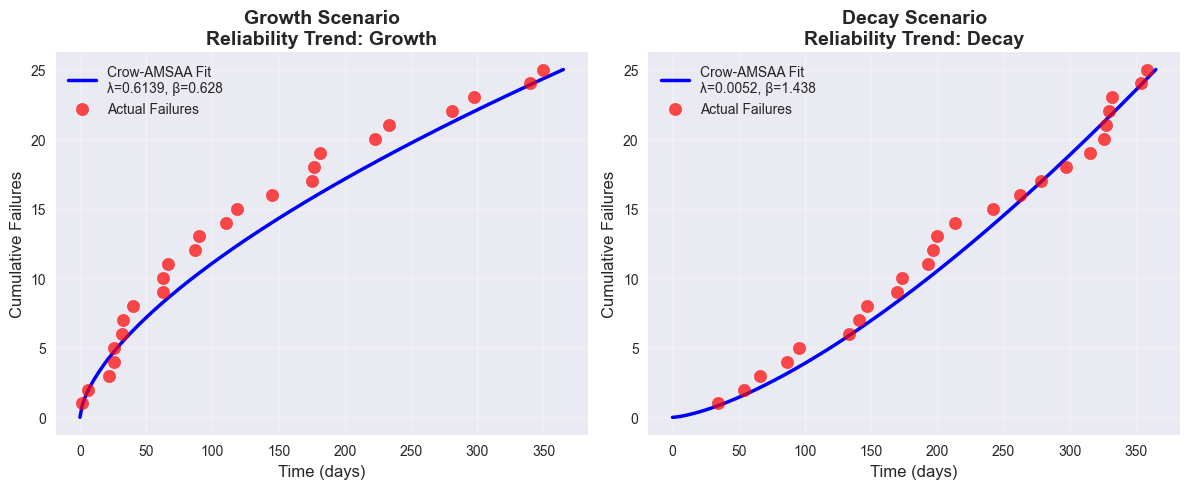

In [60]:
scenarios = ['growth', 'decay']
results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, scenario in enumerate(scenarios):
    # Generate data with different seeds for each scenario
    failure_times, censoring_time = generate_failure_data(
        scenario=scenario, 
        n_failures=25, 
        total_time=365,
        seed=42 + idx
    )
    
    if len(failure_times) < 2:
        print(f"Warning: Not enough failures for {scenario}")
        continue
    
    # Fit model
    model = CrowAMSAA()
    try:
        lambda_param, beta_param = model.fit(failure_times, censoring_time)
        trend = model.get_reliability_trend()
    except Exception as e:
        print(f"Error fitting {scenario}: {e}")
        continue
    
    results[scenario] = {
        'lambda': lambda_param,
        'beta': beta_param,
        'trend': trend,
        'failure_times': failure_times,
        'model': model
    }
    
    # Plot
    ax = axes[idx]
    
    # Time points for prediction
    time_points = np.linspace(0, censoring_time, 200)
    predicted_cumulative = [model.predict_cumulative(t) for t in time_points]
    
    # Actual cumulative failures
    actual_cumulative = np.arange(1, len(failure_times) + 1)
    
    # Plot model fit
    ax.plot(time_points, predicted_cumulative, 'b-', linewidth=2.5, 
            label=f'Crow-AMSAA Fit\nλ={lambda_param:.4f}, β={beta_param:.3f}')
    
    # Plot actual data
    ax.scatter(failure_times, actual_cumulative, color='red', 
              s=80, zorder=5, label='Actual Failures', alpha=0.7)
    
    ax.set_xlabel('Time (days)', fontsize=12)
    ax.set_ylabel('Cumulative Failures', fontsize=12)
    ax.set_title(f'{scenario.capitalize()} Scenario\nReliability Trend: {trend}', 
                fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    print(f"{scenario.capitalize()} Scenario:")
    print(f"  λ (lambda) = {lambda_param:.6f}")
    print(f"  β (beta) = {beta_param:.3f}")
    print(f"  Trend: {trend}")
    print(f"  Number of failures: {len(failure_times)}")
    print()

plt.tight_layout()
plt.show()


## Parameter Interpretation

Let's visualize what the parameters mean and how they affect predictions.


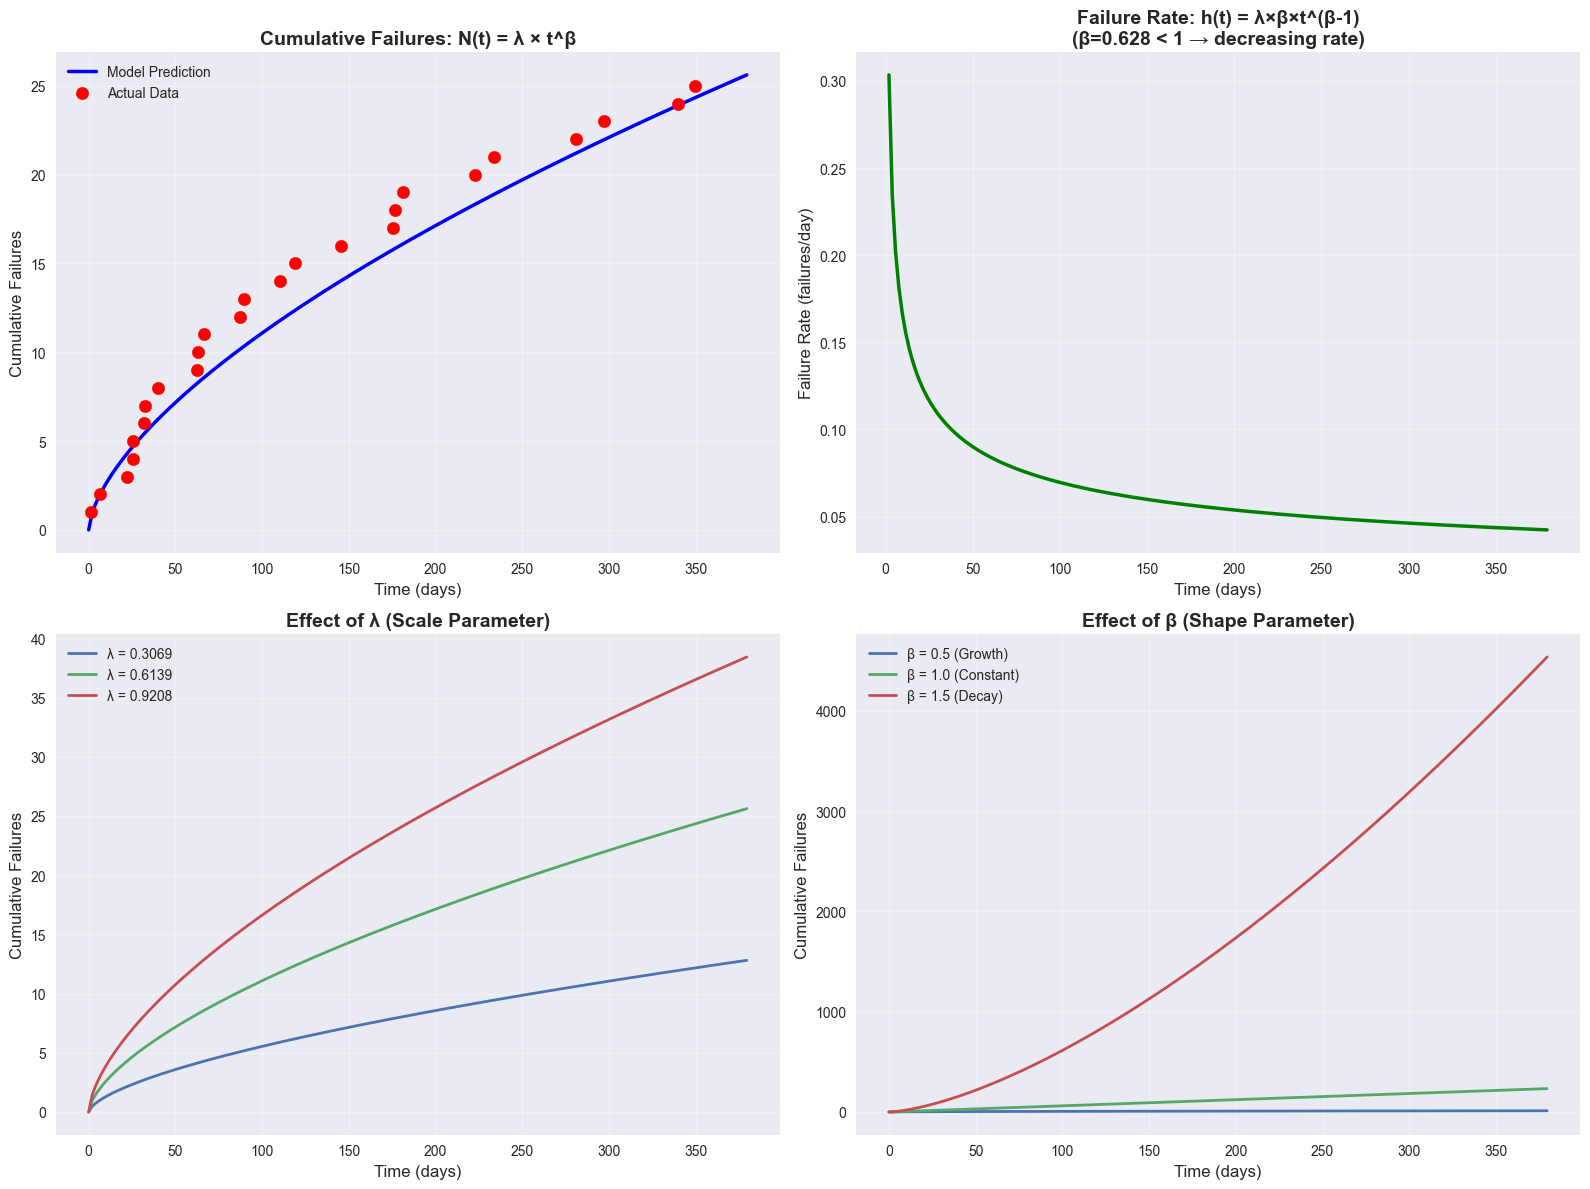


PARAMETER INTERPRETATION

λ (lambda) = 0.613855
  → Scale parameter: Higher λ means more failures overall

β (beta) = 0.628
  → Shape parameter: Growth scenario
  → β < 1: Reliability improving (failures become less frequent)
  → β = 1: Constant failure rate (exponential process)
  → β > 1: Reliability degrading (failures become more frequent)


In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get the growth scenario for detailed analysis
growth_data = results['growth']
model = growth_data['model']
failure_times = growth_data['failure_times']
censoring_time = failure_times[-1] + 30

time_points = np.linspace(0, censoring_time, 200)

# 1. Cumulative failures over time
ax = axes[0, 0]
predicted_cumulative = [model.predict_cumulative(t) for t in time_points]
actual_cumulative = np.arange(1, len(failure_times) + 1)

ax.plot(time_points, predicted_cumulative, 'b-', linewidth=2.5, label='Model Prediction')
ax.scatter(failure_times, actual_cumulative, color='red', s=80, zorder=5, label='Actual Data')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures: N(t) = λ × t^β', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Failure rate (intensity function) over time
ax = axes[0, 1]
predicted_rate = [model.predict_failure_rate(t) for t in time_points]
ax.plot(time_points, predicted_rate, 'g-', linewidth=2.5)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title(f'Failure Rate: h(t) = λ×β×t^(β-1)\n(β={model.beta_param:.3f} < 1 → decreasing rate)', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Parameter sensitivity - varying lambda
ax = axes[1, 0]
lambda_values = [model.lambda_param * 0.5, model.lambda_param, model.lambda_param * 1.5]
for lam in lambda_values:
    predicted = [lam * (t ** model.beta_param) for t in time_points]
    ax.plot(time_points, predicted, linewidth=2, 
           label=f'λ = {lam:.4f}')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Effect of λ (Scale Parameter)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Parameter sensitivity - varying beta
ax = axes[1, 1]
beta_values = [0.5, 1.0, 1.5]
for beta in beta_values:
    predicted = [model.lambda_param * (t ** beta) for t in time_points]
    trend_label = 'Growth' if beta < 1 else ('Constant' if beta == 1 else 'Decay')
    ax.plot(time_points, predicted, linewidth=2, 
           label=f'β = {beta:.1f} ({trend_label})')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Effect of β (Shape Parameter)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PARAMETER INTERPRETATION")
print("="*60)
print(f"\nλ (lambda) = {model.lambda_param:.6f}")
print("  → Scale parameter: Higher λ means more failures overall")
print(f"\nβ (beta) = {model.beta_param:.3f}")
print(f"  → Shape parameter: {growth_data['trend']} scenario")
print("  → β < 1: Reliability improving (failures become less frequent)")
print("  → β = 1: Constant failure rate (exponential process)")
print("  → β > 1: Reliability degrading (failures become more frequent)")


## Piecewise Crow-AMSAA for Changing Trends

When reliability trends change over time (e.g., PM starts/stops, equipment ages), 
a single Crow-AMSAA model may not fit well. Piecewise modeling allows different 
parameters for different time periods.


Generated 30 failures with changing trend
First 10 failures: [1.93826919e-02 4.35570357e+00 5.29665808e+00 1.07637350e+01
 1.73269440e+01 3.50089437e+01 5.28314052e+01 5.80653087e+01
 7.50388789e+01 1.06134658e+02]
Last 10 failures: [232.88020876 246.51210478 254.23859332 266.18848758 332.00995275
 334.67754104 335.43101464 335.66712072 355.53644202 361.6458432 ]

Single Crow-AMSAA Model:
  λ = 0.499965, β = 0.694, Trend: Growth

Piecewise Crow-AMSAA Model (2 segments):
  Segment 1 (t=0.0 to 146.0):
    λ = 1.130717, β = 0.474, Trend: Growth
  Segment 2 (t=146.0 to 365.0):
    λ = 0.075178, β = 1.017, Trend: Constant


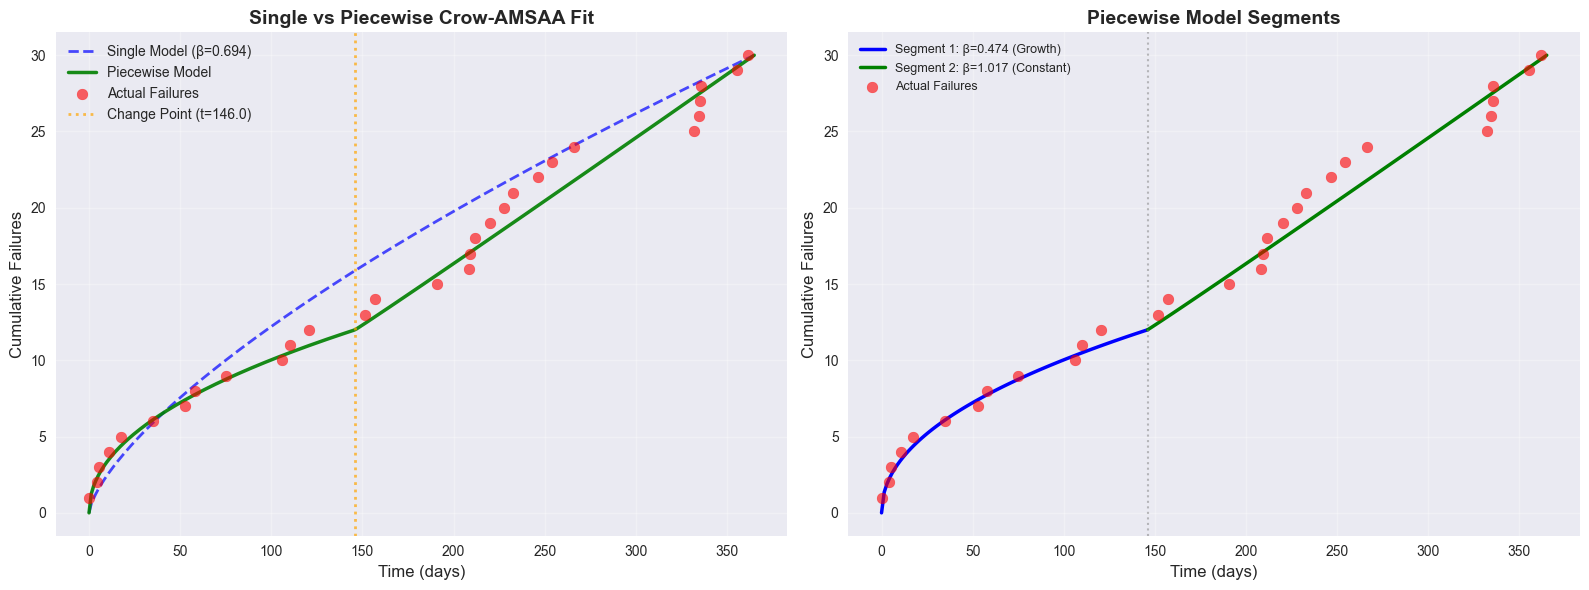


KEY INSIGHT: Piecewise model captures changing trends better!


In [62]:
# Generate data with changing trend
failure_times_piecewise, censoring_time = generate_failure_data(
    scenario='piecewise',
    n_failures=30,
    total_time=365,
    seed=100
)

print(f"Generated {len(failure_times_piecewise)} failures with changing trend")
print(f"First 10 failures: {failure_times_piecewise[:10]}")
print(f"Last 10 failures: {failure_times_piecewise[-10:]}")

# Fit single Crow-AMSAA (will average the trend)
single_model = CrowAMSAA()
lambda_single, beta_single = single_model.fit(failure_times_piecewise, censoring_time)
trend_single = single_model.get_reliability_trend()

print(f"\nSingle Crow-AMSAA Model:")
print(f"  λ = {lambda_single:.6f}, β = {beta_single:.3f}, Trend: {trend_single}")

# Fit piecewise model
piecewise_model = PiecewiseCrowAMSAA(n_segments=2)
# Estimate change point around 40% of time (where we know the change happens)
change_point = censoring_time * 0.4
segments = piecewise_model.fit(failure_times_piecewise, censoring_time, 
                               change_points=[change_point])

print(f"\nPiecewise Crow-AMSAA Model ({len(segments)} segments):")
for i, seg in enumerate(segments):
    print(f"  Segment {i+1} (t={seg['start']:.1f} to {seg['end']:.1f}):")
    print(f"    λ = {seg['lambda']:.6f}, β = {seg['beta']:.3f}, Trend: {seg['model'].get_reliability_trend()}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Single vs Piecewise fit
ax = axes[0]
time_points = np.linspace(0, censoring_time, 300)
actual_cumulative = np.arange(1, len(failure_times_piecewise) + 1)

# Single model prediction
predicted_single = [single_model.predict_cumulative(t) for t in time_points]
ax.plot(time_points, predicted_single, 'b--', linewidth=2, 
        label=f'Single Model (β={beta_single:.3f})', alpha=0.7)

# Piecewise model prediction
predicted_piecewise = [piecewise_model.predict_cumulative(t) for t in time_points]
ax.plot(time_points, predicted_piecewise, 'g-', linewidth=2.5, 
        label='Piecewise Model', alpha=0.9)

# Actual data
ax.scatter(failure_times_piecewise, actual_cumulative, color='red', 
          s=60, zorder=5, label='Actual Failures', alpha=0.6)

# Mark change point
ax.axvline(change_point, color='orange', linestyle=':', linewidth=2, 
          label=f'Change Point (t={change_point:.1f})', alpha=0.7)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Single vs Piecewise Crow-AMSAA Fit', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Segment parameters
ax = axes[1]
segment_colors = ['blue', 'green', 'purple', 'orange']
for i, seg in enumerate(segments):
    seg_times = np.linspace(seg['start'], seg['end'], 100)
    seg_cumulative = [piecewise_model.predict_cumulative(t) for t in seg_times]
    
    ax.plot(seg_times, seg_cumulative, color=segment_colors[i % len(segment_colors)],
           linewidth=2.5, label=f"Segment {i+1}: β={seg['beta']:.3f} ({seg['model'].get_reliability_trend()})")

# Actual data
ax.scatter(failure_times_piecewise, actual_cumulative, color='red', 
          s=60, zorder=5, label='Actual Failures', alpha=0.6)

# Mark change points
for seg in segments[:-1]:
    ax.axvline(seg['end'], color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Piecewise Model Segments', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Piecewise model captures changing trends better!")
print("="*60)


In [63]:
def find_optimal_change_point(failure_times, censoring_time, model_class, 
                              n_segments=2, min_frac=0.2, max_frac=0.8, n_points=30):
    """
    Find optimal change point(s) for piecewise model using grid search with AIC.
    
    Parameters:
    -----------
    failure_times : array-like
        Failure times
    censoring_time : float
        Total observation time
    model_class : class
        PiecewiseCrowAMSAA, PiecewiseCoxLewis, PiecewiseWeibullNHPP, or PiecewiseGompertz
    n_segments : int
        Number of segments (default: 2)
    min_frac : float
        Minimum fraction of time to search (default: 0.2)
    max_frac : float
        Maximum fraction of time to search (default: 0.8)
    n_points : int
        Number of change points to test (default: 30)
    
    Returns:
    --------
    best_change_point : float
        Optimal change point
    best_aic : float
        Best AIC value
    results : list
        All tested change points and their AIC values
    best_segments : list
        Segments from best model
    """
    failure_times = np.sort(failure_times)
    n = len(failure_times)
    
    # Test different change points
    change_points_to_test = np.linspace(
        censoring_time * min_frac, 
        censoring_time * max_frac, 
        n_points
    )
    
    results = []
    best_aic = np.inf
    best_change_point = None
    best_segments = None
    
    for cp in change_points_to_test:
        try:
            # Fit piecewise model with this change point
            model = model_class(n_segments=n_segments)
            segments = model.fit(failure_times, censoring_time, change_points=[cp])
            
            if len(segments) < n_segments:
                continue
            
            # Calculate AIC (Akaike Information Criterion)
            # AIC = 2k - 2ln(L), where k = number of parameters, L = likelihood
            # Lower AIC is better
            
            # Count parameters: each segment has 2 parameters (λ,β or α,γ)
            k = len(segments) * 2
            
            # Calculate log-likelihood
            log_likelihood = 0
            for segment in segments:
                seg_model = segment['model']
                seg_start = segment['start']
                seg_end = segment['end']
                
                # Get failures in this segment
                seg_failures = failure_times[
                    (failure_times >= seg_start) & (failure_times < seg_end)
                ]
                if len(seg_failures) < 2:
                    continue
                
                seg_failures_shifted = seg_failures - seg_start
                seg_censoring = seg_end - seg_start
                
                # Calculate log-likelihood for this segment
                if isinstance(seg_model, CrowAMSAA):
                    # Crow-AMSAA log-likelihood
                    lambda_param = seg_model.lambda_param
                    beta_param = seg_model.beta_param
                    
                    # Log-likelihood for Crow-AMSAA
                    if len(seg_failures_shifted) > 0 and seg_censoring > 0:
                        log_likelihood += (
                            len(seg_failures_shifted) * np.log(lambda_param * beta_param) +
                            (beta_param - 1) * np.sum(np.log(seg_failures_shifted)) -
                            lambda_param * (seg_censoring ** beta_param)
                        )
                elif isinstance(seg_model, CoxLewis):
                    # Cox-Lewis log-likelihood
                    alpha = seg_model.alpha_param
                    gamma = seg_model.gamma_param
                    
                    if abs(gamma) < 1e-10:
                        integral = np.exp(alpha) * seg_censoring
                    else:
                        integral = (np.exp(alpha) / gamma) * (np.exp(gamma * seg_censoring) - 1)
                    
                    if len(seg_failures_shifted) > 0:
                        log_likelihood += np.sum(alpha + gamma * seg_failures_shifted) - integral
                elif isinstance(seg_model, WeibullNHPP):
                    # Weibull NHPP log-likelihood
                    eta = seg_model.eta_param
                    beta = seg_model.beta_param
                    
                    if len(seg_failures_shifted) > 0 and seg_censoring > 0:
                        log_likelihood += (
                            len(seg_failures_shifted) * np.log(beta / eta) +
                            (beta - 1) * np.sum(np.log(seg_failures_shifted / eta)) -
                            (seg_censoring / eta) ** beta
                        )
                elif isinstance(seg_model, Gompertz):
                    # Gompertz log-likelihood (approximate using cumulative predictions)
                    # For simplicity, use a basic approximation
                    if len(seg_failures_shifted) > 0:
                        # Use predicted cumulative at censoring time
                        N_censoring = seg_model.predict_cumulative(seg_censoring)
                        # Approximate log-likelihood
                        for t in seg_failures_shifted:
                            if t > 0:
                                lambda_t = seg_model.predict_failure_rate(t)
                                if lambda_t > 0:
                                    log_likelihood += np.log(lambda_t)
                        log_likelihood -= N_censoring
            
            # Calculate AIC
            aic = 2 * k - 2 * log_likelihood
            
            results.append({
                'change_point': cp,
                'aic': aic,
                'log_likelihood': log_likelihood,
                'n_params': k
            })
            
            if aic < best_aic:
                best_aic = aic
                best_change_point = cp
                best_segments = segments
                
        except Exception as e:
            continue
    
    return best_change_point, best_aic, results, best_segments


## Model Comparison: Crow-AMSAA vs Cox-Lewis

Let's compare both models on the same data to see which fits better.


Test data: 20 failures over 300.0 days

Crow-AMSAA Model:
  λ = 0.111819, β = 0.909
  Trend: Growth
  Interpretation: β < 1 means reliability improving

Cox-Lewis Model:
  α = -2.3177, γ = -0.002797
  Trend: Constant
  Interpretation: γ < 0 means reliability improving

Gompertz Model:
  a = 2041.6032, b = 0.0123, c = 0.9951
  Trend: Slow Growth
  Interpretation: c < 1 means reliability improving (saturating at a)

Weibull NHPP Model:
  η (eta) = 11.1265, β (beta) = 0.909
  Trend: Growth
  Interpretation: β < 1 means reliability improving

Piecewise Weibull NHPP Model:
  Optimal change point: 84.8 days (28.3% of total time, AIC: 142.63)
  Segment 1 (0-84.8): η=31.1736, β=2.395
  Segment 2 (0-300.0): η=46.4768, β=1.434

Piecewise Gompertz Model:
  Optimal change point: 84.8 days (28.3% of total time, AIC: 42.14)
  Segment 1 (0-84.8): a=1581.0818, b=0.0689, c=0.9990
  Segment 2 (0-300.0): a=1162.0160, b=0.0367, c=0.9990

ALL MODELS COMPARISON
✓ Gompertz model plotted
✓ Weibull NHPP model 

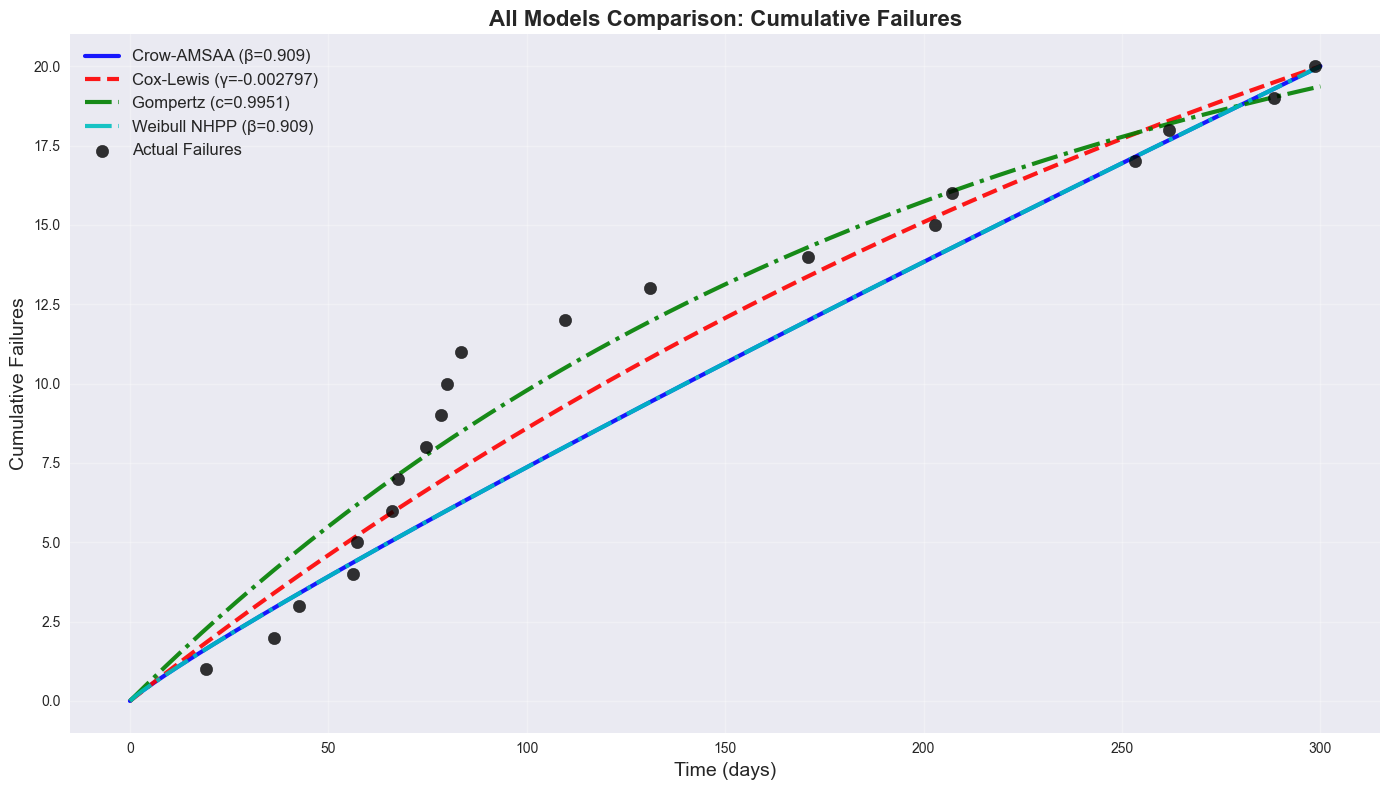

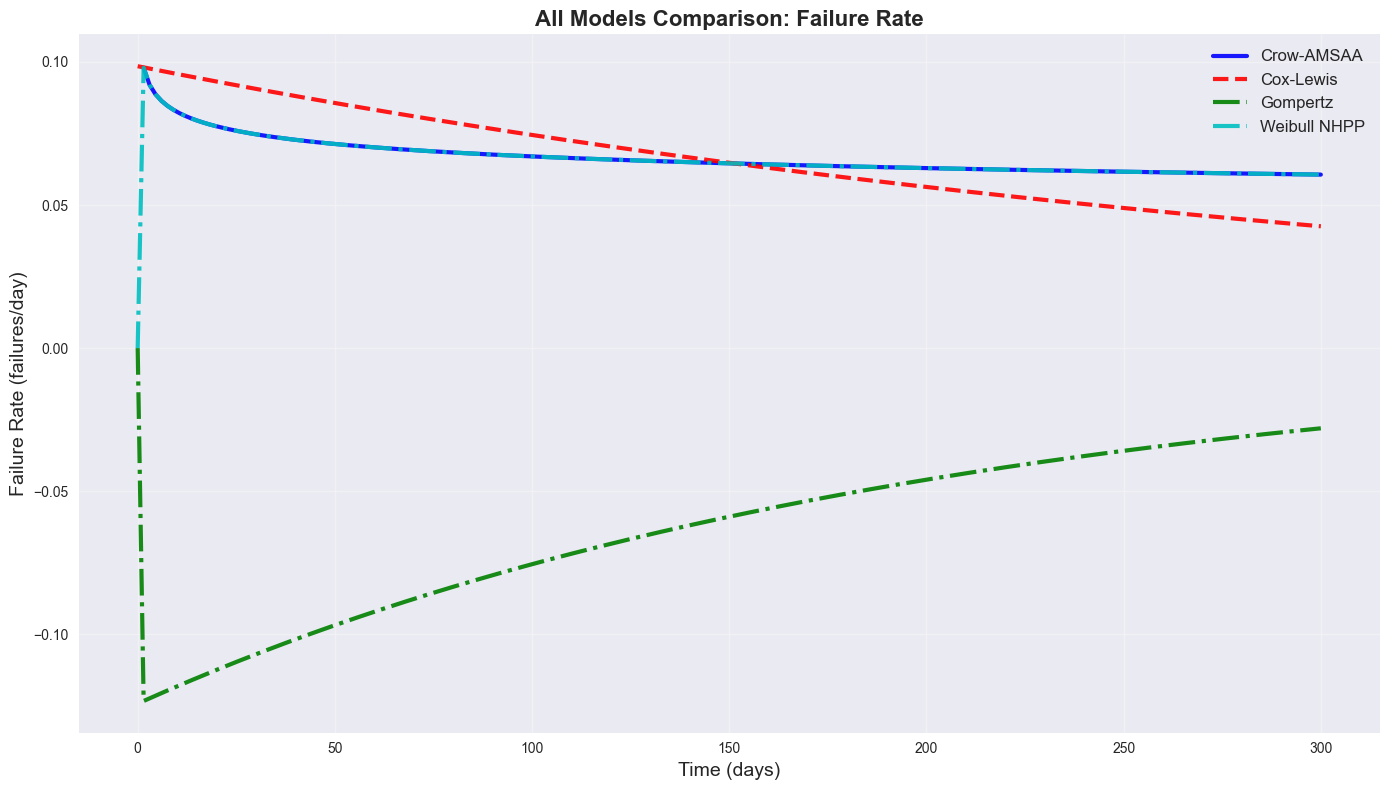


Optimal change point (Crow-AMSAA): 84.8 days (28.3% of total time, AIC: 142.63)


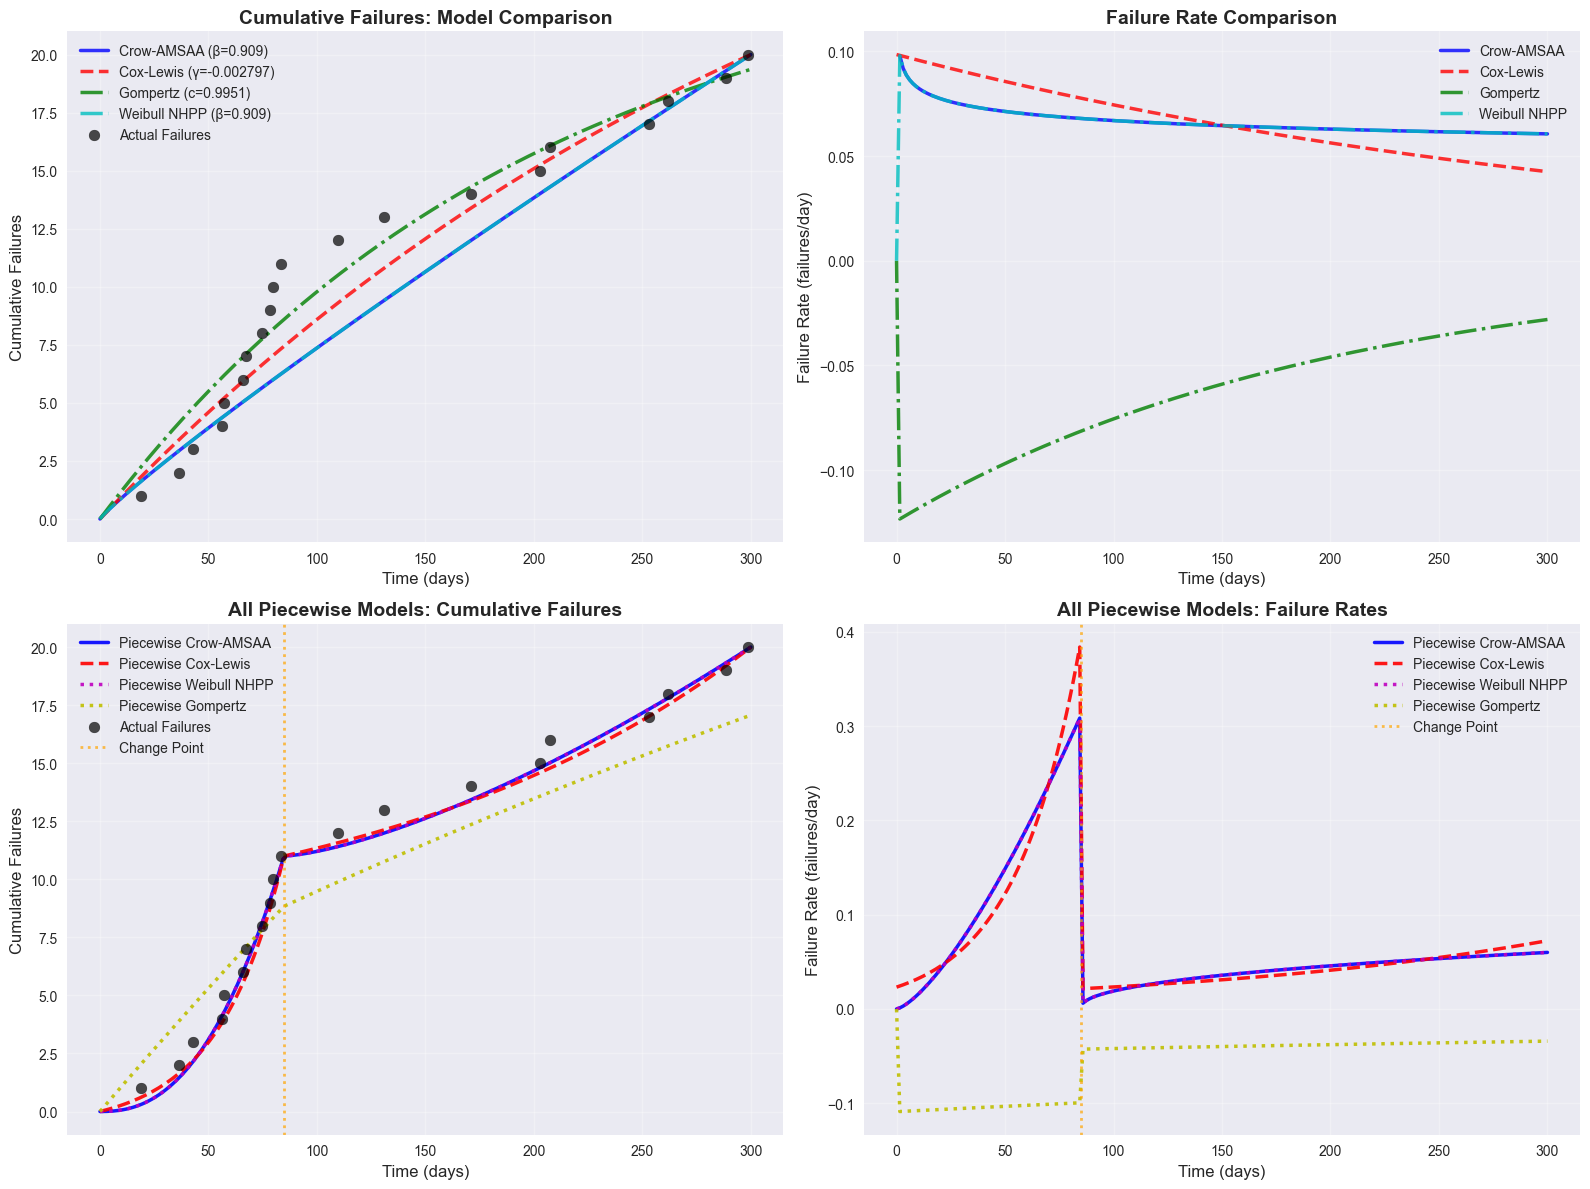


Piecewise Model Segments:
Crow-AMSAA:
  Segment 1: λ=0.0003, β=2.395 (Decay)
  Segment 2: λ=0.0041, β=1.434 (Decay)

Cox-Lewis:
  Segment 1: α=-3.7663, γ=0.033272 (Decay)
  Segment 2: α=-3.8453, γ=0.005669 (Constant)


In [64]:
# Generate test data for comparison
np.random.seed(50)
test_failures, test_censoring = generate_failure_data(
    scenario='growth',
    n_failures=20,
    total_time=300,
    seed=50
)

print(f"Test data: {len(test_failures)} failures over {test_censoring:.1f} days\n")

# Fit both models
ca_model = CrowAMSAA()
ca_lambda, ca_beta = ca_model.fit(test_failures, test_censoring)
ca_trend = ca_model.get_reliability_trend()

cl_model = CoxLewis()
cl_alpha, cl_gamma = cl_model.fit(test_failures, test_censoring)
cl_trend = cl_model.get_reliability_trend()

print("Crow-AMSAA Model:")
print(f"  λ = {ca_lambda:.6f}, β = {ca_beta:.3f}")
print(f"  Trend: {ca_trend}")
print(f"  Interpretation: β < 1 means reliability improving")

print("\nCox-Lewis Model:")
print(f"  α = {cl_alpha:.4f}, γ = {cl_gamma:.6f}")
print(f"  Trend: {cl_trend}")
print(f"  Interpretation: γ < 0 means reliability improving")

# Fit Gompertz model
try:
    gompertz_model = Gompertz()
    gom_a, gom_b, gom_c = gompertz_model.fit(test_failures, test_censoring)
    gom_trend = gompertz_model.get_reliability_trend()
    print("\nGompertz Model:")
    print(f"  a = {gom_a:.4f}, b = {gom_b:.4f}, c = {gom_c:.4f}")
    print(f"  Trend: {gom_trend}")
    print(f"  Interpretation: c < 1 means reliability improving (saturating at a)")
except Exception as e:
    print(f"\nGompertz Model: Failed to fit - {e}")
    gompertz_model = None

# Fit Weibull NHPP model
try:
    weibull_model = WeibullNHPP()
    wb_eta, wb_beta = weibull_model.fit(test_failures, test_censoring)
    wb_trend = weibull_model.get_reliability_trend()
    print("\nWeibull NHPP Model:")
    print(f"  η (eta) = {wb_eta:.4f}, β (beta) = {wb_beta:.3f}")
    print(f"  Trend: {wb_trend}")
    print(f"  Interpretation: β < 1 means reliability improving")
except Exception as e:
    print(f"\nWeibull NHPP Model: Failed to fit - {e}")
    weibull_model = None

# Fit Piecewise Weibull NHPP model
try:
    pw_wb = PiecewiseWeibullNHPP(n_segments=2)
    optimal_cp_wb, best_aic_wb, cp_results_wb, _ = find_optimal_change_point(
        test_failures,
        test_censoring,
        PiecewiseWeibullNHPP,
        n_segments=2,
        min_frac=0.2,
        max_frac=0.8,
        n_points=30
    )
    if optimal_cp_wb is not None:
        pw_wb_segments = pw_wb.fit(test_failures, test_censoring, change_points=[optimal_cp_wb])
        print("\nPiecewise Weibull NHPP Model:")
        print(f"  Optimal change point: {optimal_cp_wb:.1f} days ({optimal_cp_wb/test_censoring*100:.1f}% of total time, AIC: {best_aic_wb:.2f})")
        for i, seg in enumerate(pw_wb_segments):
            print(f"  Segment {i+1} (0-{seg['end']:.1f}): η={seg['eta']:.4f}, β={seg['beta']:.3f}")
    else:
        pw_wb = None
except Exception as e:
    print(f"\nPiecewise Weibull NHPP Model: Failed to fit - {e}")
    pw_wb = None

# Fit Piecewise Gompertz model
try:
    pw_gom = PiecewiseGompertz(n_segments=2)
    optimal_cp_gom, best_aic_gom, cp_results_gom, _ = find_optimal_change_point(
        test_failures,
        test_censoring,
        PiecewiseGompertz,
        n_segments=2,
        min_frac=0.2,
        max_frac=0.8,
        n_points=30
    )
    if optimal_cp_gom is not None:
        pw_gom_segments = pw_gom.fit(test_failures, test_censoring, change_points=[optimal_cp_gom])
        print("\nPiecewise Gompertz Model:")
        print(f"  Optimal change point: {optimal_cp_gom:.1f} days ({optimal_cp_gom/test_censoring*100:.1f}% of total time, AIC: {best_aic_gom:.2f})")
        for i, seg in enumerate(pw_gom_segments):
            print(f"  Segment {i+1} (0-{seg['end']:.1f}): a={seg['a']:.4f}, b={seg['b']:.4f}, c={seg['c']:.4f}")
    else:
        pw_gom = None
except Exception as e:
    print(f"\nPiecewise Gompertz Model: Failed to fit - {e}")
    pw_gom = None

# Create a dedicated comparison plot for all models
print("\n" + "="*60)
print("ALL MODELS COMPARISON")
print("="*60)

fig_all, ax_all = plt.subplots(1, 1, figsize=(14, 8))

time_points = np.linspace(0, test_censoring, 200)
actual_cumulative = np.arange(1, len(test_failures) + 1)

# Plot all models
ca_cumulative = [ca_model.predict_cumulative(t) for t in time_points]
cl_cumulative = [cl_model.predict_cumulative(t) for t in time_points]

ax_all.plot(time_points, ca_cumulative, 'b-', linewidth=3, 
            label=f'Crow-AMSAA (β={ca_beta:.3f})', alpha=0.9)
ax_all.plot(time_points, cl_cumulative, 'r--', linewidth=3, 
            label=f'Cox-Lewis (γ={cl_gamma:.6f})', alpha=0.9)

if gompertz_model is not None and gompertz_model.fitted:
    gom_cumulative = [gompertz_model.predict_cumulative(t) for t in time_points]
    ax_all.plot(time_points, gom_cumulative, 'g-.', linewidth=3, 
                label=f'Gompertz (c={gom_c:.4f})', alpha=0.9)
    print(f"✓ Gompertz model plotted")

if weibull_model is not None and weibull_model.fitted:
    wb_cumulative = [weibull_model.predict_cumulative(t) for t in time_points]
    ax_all.plot(time_points, wb_cumulative, 'c-.', linewidth=3, 
                label=f'Weibull NHPP (β={wb_beta:.3f})', alpha=0.9)
    print(f"✓ Weibull NHPP model plotted")

ax_all.scatter(test_failures, actual_cumulative, color='black', 
              s=80, zorder=5, label='Actual Failures', alpha=0.8)
ax_all.set_xlabel('Time (days)', fontsize=14)
ax_all.set_ylabel('Cumulative Failures', fontsize=14)
ax_all.set_title('All Models Comparison: Cumulative Failures', fontsize=16, fontweight='bold')
ax_all.legend(fontsize=12, loc='best')
ax_all.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Create failure rate comparison for all models
fig_rates, ax_rates = plt.subplots(1, 1, figsize=(14, 8))

ca_rates = [ca_model.predict_failure_rate(t) for t in time_points]
cl_rates = [cl_model.predict_failure_rate(t) for t in time_points]

ax_rates.plot(time_points, ca_rates, 'b-', linewidth=3, 
              label='Crow-AMSAA', alpha=0.9)
ax_rates.plot(time_points, cl_rates, 'r--', linewidth=3, 
              label='Cox-Lewis', alpha=0.9)

if gompertz_model is not None and gompertz_model.fitted:
    gom_rates = [gompertz_model.predict_failure_rate(t) for t in time_points]
    ax_rates.plot(time_points, gom_rates, 'g-.', linewidth=3, 
                  label='Gompertz', alpha=0.9)

if weibull_model is not None and weibull_model.fitted:
    wb_rates = [weibull_model.predict_failure_rate(t) for t in time_points]
    ax_rates.plot(time_points, wb_rates, 'c-.', linewidth=3, 
                  label='Weibull NHPP', alpha=0.9)

ax_rates.set_xlabel('Time (days)', fontsize=14)
ax_rates.set_ylabel('Failure Rate (failures/day)', fontsize=14)
ax_rates.set_title('All Models Comparison: Failure Rate', fontsize=16, fontweight='bold')
ax_rates.legend(fontsize=12, loc='best')
ax_rates.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

time_points = np.linspace(0, test_censoring, 200)
actual_cumulative = np.arange(1, len(test_failures) + 1)

# Plot 1: Cumulative failures comparison
ax = axes[0, 0]
ca_cumulative = [ca_model.predict_cumulative(t) for t in time_points]
cl_cumulative = [cl_model.predict_cumulative(t) for t in time_points]

ax.plot(time_points, ca_cumulative, 'b-', linewidth=2.5, 
        label=f'Crow-AMSAA (β={ca_beta:.3f})', alpha=0.8)
ax.plot(time_points, cl_cumulative, 'r--', linewidth=2.5, 
        label=f'Cox-Lewis (γ={cl_gamma:.6f})', alpha=0.8)

# Add Gompertz model if fitted
if gompertz_model is not None and gompertz_model.fitted:
    gom_cumulative = [gompertz_model.predict_cumulative(t) for t in time_points]
    ax.plot(time_points, gom_cumulative, 'g-.', linewidth=2.5, 
            label=f'Gompertz (c={gom_c:.4f})', alpha=0.8)

# Add Weibull NHPP model if fitted
if weibull_model is not None and weibull_model.fitted:
    wb_cumulative = [weibull_model.predict_cumulative(t) for t in time_points]
    ax.plot(time_points, wb_cumulative, 'c-.', linewidth=2.5, 
            label=f'Weibull NHPP (β={wb_beta:.3f})', alpha=0.8)

ax.scatter(test_failures, actual_cumulative, color='black', 
          s=60, zorder=5, label='Actual Failures', alpha=0.7)
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('Cumulative Failures: Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Failure rate comparison
ax = axes[0, 1]
ca_rates = [ca_model.predict_failure_rate(t) for t in time_points]
cl_rates = [cl_model.predict_failure_rate(t) for t in time_points]

ax.plot(time_points, ca_rates, 'b-', linewidth=2.5, 
        label='Crow-AMSAA', alpha=0.8)
ax.plot(time_points, cl_rates, 'r--', linewidth=2.5, 
        label='Cox-Lewis', alpha=0.8)

# Add Gompertz model if fitted
if gompertz_model is not None and gompertz_model.fitted:
    gom_rates = [gompertz_model.predict_failure_rate(t) for t in time_points]
    ax.plot(time_points, gom_rates, 'g-.', linewidth=2.5, 
            label='Gompertz', alpha=0.8)

# Add Weibull NHPP model if fitted
if weibull_model is not None and weibull_model.fitted:
    wb_rates = [weibull_model.predict_failure_rate(t) for t in time_points]
    ax.plot(time_points, wb_rates, 'c-.', linewidth=2.5, 
            label='Weibull NHPP', alpha=0.8)

ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('Failure Rate Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: All Piecewise Models - Cumulative Failures
ax = axes[1, 0]

# Fit piecewise Crow-AMSAA if not already fitted
pw_ca = PiecewiseCrowAMSAA(n_segments=2)
optimal_cp_ca, best_aic_ca, cp_results_ca, _ = find_optimal_change_point(
    test_failures, 
    test_censoring, 
    PiecewiseCrowAMSAA,
    n_segments=2,
    min_frac=0.2,
    max_frac=0.8,
    n_points=30
)
if optimal_cp_ca is not None:
    change_point = optimal_cp_ca
    print(f"\nOptimal change point (Crow-AMSAA): {optimal_cp_ca:.1f} days ({optimal_cp_ca/test_censoring*100:.1f}% of total time, AIC: {best_aic_ca:.2f})")
else:
    change_point = test_censoring * 0.5
    print(f"\nUsing default change point: {change_point:.1f} days (50% of total time)")

pw_ca_segments = pw_ca.fit(test_failures, test_censoring, change_points=[change_point])
pw_ca_cumulative = [pw_ca.predict_cumulative(t) for t in time_points]
ax.plot(time_points, pw_ca_cumulative, 'b-', linewidth=2.5, 
        label='Piecewise Crow-AMSAA', alpha=0.9)

# Fit piecewise Cox-Lewis
pw_cl = PiecewiseCoxLewis(n_segments=2)
pw_cl_segments = pw_cl.fit(test_failures, test_censoring, change_points=[change_point])
pw_cl_cumulative = [pw_cl.predict_cumulative(t) for t in time_points]
ax.plot(time_points, pw_cl_cumulative, 'r--', linewidth=2.5, 
        label='Piecewise Cox-Lewis', alpha=0.9)

# Add piecewise Weibull NHPP if fitted
if pw_wb is not None and pw_wb.fitted:
    pw_wb_cumulative = [pw_wb.predict_cumulative(t) for t in time_points]
    ax.plot(time_points, pw_wb_cumulative, 'm:', linewidth=2.5, 
            label='Piecewise Weibull NHPP', alpha=0.9)

# Add piecewise Gompertz if fitted
if pw_gom is not None and pw_gom.fitted:
    pw_gom_cumulative = [pw_gom.predict_cumulative(t) for t in time_points]
    ax.plot(time_points, pw_gom_cumulative, 'y:', linewidth=2.5, 
            label='Piecewise Gompertz', alpha=0.9)

ax.scatter(test_failures, actual_cumulative, color='black', 
          s=60, zorder=5, label='Actual Failures', alpha=0.7)
ax.axvline(change_point, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Change Point')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Cumulative Failures', fontsize=12)
ax.set_title('All Piecewise Models: Cumulative Failures', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: All Piecewise Models - Failure Rates
ax = axes[1, 1]

pw_ca_rates = [pw_ca.predict_failure_rate(t) for t in time_points]
ax.plot(time_points, pw_ca_rates, 'b-', linewidth=2.5, 
        label='Piecewise Crow-AMSAA', alpha=0.9)

pw_cl_rates = [pw_cl.predict_failure_rate(t) for t in time_points]
ax.plot(time_points, pw_cl_rates, 'r--', linewidth=2.5, 
        label='Piecewise Cox-Lewis', alpha=0.9)

# Add piecewise Weibull NHPP if fitted
if pw_wb is not None and pw_wb.fitted:
    pw_wb_rates = [pw_wb.predict_failure_rate(t) for t in time_points]
    ax.plot(time_points, pw_wb_rates, 'm:', linewidth=2.5, 
            label='Piecewise Weibull NHPP', alpha=0.9)

# Add piecewise Gompertz if fitted
if pw_gom is not None and pw_gom.fitted:
    pw_gom_rates = [pw_gom.predict_failure_rate(t) for t in time_points]
    ax.plot(time_points, pw_gom_rates, 'y:', linewidth=2.5, 
            label='Piecewise Gompertz', alpha=0.9)

ax.axvline(change_point, color='orange', linestyle=':', linewidth=2, alpha=0.7, label='Change Point')
ax.set_xlabel('Time (days)', fontsize=12)
ax.set_ylabel('Failure Rate (failures/day)', fontsize=12)
ax.set_title('All Piecewise Models: Failure Rates', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPiecewise Model Segments:")
print("Crow-AMSAA:")
for i, seg in enumerate(pw_ca_segments):
    print(f"  Segment {i+1}: λ={seg['lambda']:.4f}, β={seg['beta']:.3f} ({seg['model'].get_reliability_trend()})")
print("\nCox-Lewis:")
for i, seg in enumerate(pw_cl_segments):
    print(f"  Segment {i+1}: α={seg['alpha']:.4f}, γ={seg['gamma']:.6f} ({seg['model'].get_reliability_trend()})")


## Model Selection Guide

### Crow-AMSAA Model
**Formula**: N(t) = λ × t^β, Failure Rate: λ(t) = λβt^(β-1)

**Best for:**
- Power-law failure patterns
- Systems with clear reliability growth/decay trends
- When β parameter interpretation is important
- Long-term reliability analysis

**Parameters:**
- **λ (lambda)**: Scale parameter (overall failure intensity)
- **β (beta)**: Shape parameter
  - β < 1: Reliability improving (failures become less frequent)
  - β = 1: Constant failure rate
  - β > 1: Reliability degrading (failures become more frequent)

### Cox-Lewis Model
**Formula**: Failure Rate: λ(t) = exp(α + γt), Cumulative: Λ(t) = (exp(α)/γ)(exp(γt)-1)

**Best for:**
- Exponential failure rate patterns
- Systems with exponential growth/decay
- When γ parameter interpretation is clearer
- Short to medium-term analysis

**Parameters:**
- **α (alpha)**: Baseline failure rate (log scale)
- **γ (gamma)**: Trend parameter
  - γ < 0: Reliability improving (exponential decrease)
  - γ = 0: Constant failure rate
  - γ > 0: Reliability degrading (exponential increase)

### Gompertz Model
**Formula**: N(t) = a × (1 - b^(c^t)), Failure Rate: λ(t) = -a×ln(b)×ln(c)×c^t×b^(c^t)

**Best for:**
- Systems with S-shaped reliability growth
- Reliability that approaches an upper limit
- Long-term analysis where improvement saturates
- When initial rapid improvement slows over time

**Parameters:**
- **a**: Asymptotic reliability (upper limit of cumulative failures)
- **b**: Initial reliability parameter
- **c**: Growth rate parameter (0 < c < 1)
  - c close to 0: Rapid initial growth
  - c close to 1: Slow, gradual growth

### Weibull NHPP Model
**Formula**: N(t) = (t/η)^β, Failure Rate: λ(t) = (β/η) × (t/η)^(β-1)

**Best for:**
- Flexible hazard rate modeling
- Systems with wear-out patterns
- When you need to model increasing, decreasing, or constant failure rates
- Equipment with characteristic life patterns

**Parameters:**
- **η (eta)**: Scale parameter (characteristic life)
- **β (beta)**: Shape parameter
  - β < 1: Decreasing failure rate (reliability growth)
  - β = 1: Constant failure rate (exponential)
  - β > 1: Increasing failure rate (wear-out/decay)

### Piecewise Models
**Use when:**
- Trends change over time (e.g., PM starts/stops)
- Equipment behavior changes
- Different phases in equipment lifecycle
- Need to identify change points

**Both models support piecewise fitting** to capture changing trends!


## Key Takeaways

### Model Parameters as Features

All reliability models provide meaningful parameters that can be used as features in predictive models:

**Crow-AMSAA Features:**
- **λ (lambda)**: Overall failure intensity - compare across equipment/time periods
- **β (beta)**: Reliability trend indicator
  - Lower β (< 1) = better reliability trend (PM may be working)
  - Higher β (> 1) = degrading reliability (aging/wear-out)

**Cox-Lewis Features:**
- **α (alpha)**: Baseline failure rate on log scale
- **γ (gamma)**: Exponential trend indicator
  - Negative γ = improving reliability
  - Positive γ = degrading reliability

**Gompertz Features:**
- **a**: Asymptotic reliability limit - maximum expected failures
- **b**: Initial reliability state
- **c**: Growth rate - how quickly reliability improves
  - Lower c = faster initial improvement
  - Higher c = slower, more gradual improvement

**Weibull NHPP Features:**
- **η (eta)**: Characteristic life - typical time scale for failures
- **β (beta)**: Shape parameter - failure rate trend
  - Lower β (< 1) = improving reliability
  - Higher β (> 1) = wear-out pattern

### Piecewise Modeling Benefits

- **Captures changing trends**: When PM starts/stops or equipment behavior changes
- **Identifies change points**: When reliability trend shifts
- **Better fit**: More accurate than single-parameter models for complex patterns
- **Segment parameters**: Each phase gets its own parameters for detailed analysis

### Using Parameters for PM Effectiveness Assessment

1. **Compare parameters before/after PM implementation**
   - Lower β (Crow-AMSAA/Weibull) or negative γ (Cox-Lewis) after PM = PM is working
   - Lower c (Gompertz) = faster improvement from PM
   - No change = PM has no effect
   - Higher β or positive γ = PM not effective or equipment degrading

2. **Track parameters over time**
   - Monitor how β, γ, or c changes as PM program evolves
   - Identify when PM effectiveness changes
   - Use Gompertz 'a' parameter to estimate maximum achievable reliability

3. **Use as ML features**
   - Include λ, β (Crow-AMSAA/Weibull), α, γ (Cox-Lewis), or a, b, c (Gompertz) as features
   - Add piecewise segment parameters for more granular analysis
   - Compare models to see which fits your data better
   - Use multiple model parameters for ensemble predictions

**These continuous parameters provide quantitative measures of preventive maintenance effectiveness!**
